# Baseline model - Random Forest

In [2]:
# Cell 1 - Imports and Setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Add src/ to path to use project config
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
sys.path.insert(0, '../src')
from config import (
    MOLECULES, N_MOLECULES, RANDOM_SEED, STRONG_FEATURES,
    WEAK_FEATURES, BIOSIGNATURES, LOG_VMR_MIN, LOG_VMR_MAX,
    TRAIN_FRAC, VAL_FRAC, TEST_FRAC
)

print("All libraries loaded ✓")
print(f"Molecules: {MOLECULES}")

All libraries loaded ✓
Molecules: ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']


In [3]:
# Cell 2 - Load Data from inara_data/processed
## we need to remove npy files from inara_data folder. it should be under processed
DATA_DIR = os.path.join('..', 'inara_data/processed')

spectra     = np.load(os.path.join(DATA_DIR, 'spectra.npy'))
molecules   = np.load(os.path.join(DATA_DIR, 'molecules.npy'))
aux_params  = np.load(os.path.join(DATA_DIR, 'aux_params.npy'))
wavelengths = np.load(os.path.join(DATA_DIR, 'wavelengths.npy'))
params_df   = pd.read_csv(os.path.join(DATA_DIR, 'parameters_processed.csv'))

print(f"Spectra shape:     {spectra.shape}")
print(f"Molecules shape:   {molecules.shape}")
print(f"Aux params shape:  {aux_params.shape}")
print(f"Wavelengths shape: {wavelengths.shape}")
print(f"Params df shape:   {params_df.shape}")
print(f"\nInput channels:")
print(f"  Ch0 - Normalised SNR:    {spectra[:,0,:].shape}")
print(f"  Ch1 - Mean Subtracted:   {spectra[:,1,:].shape}")
print(f"  Ch2 - Log Transit Depth: {spectra[:,2,:].shape}")

Spectra shape:     (10000, 3, 4378)
Molecules shape:   (10000, 12)
Aux params shape:  (10000, 8)
Wavelengths shape: (4378,)
Params df shape:   (10000, 21)

Input channels:
  Ch0 - Normalised SNR:    (10000, 4378)
  Ch1 - Mean Subtracted:   (10000, 4378)
  Ch2 - Log Transit Depth: (10000, 4378)


In [4]:
"""

------------------------------------------------------------
SKIP THIS PART AND CONTINUE WITH ORIGINAL RECORDS
------------------------------------------------------------
# Cell 3 - Generated demo data ---
from download_inara import generate_demo

PROCESSED_DIR = os.path.join('..', 'inara_data', 'processed')

# Generating  samples 
print("Generating 20,000 synthetic samples...")
generate_demo(output_dir=PROCESSED_DIR, n_samples=20000)
print("Done ✓")
"""
#
print("Skip synthetic data generation.")

Skip synthetic data generation.


In [5]:
# Cell 4 - Loading dataset
PROCESSED_DIR = os.path.join('..', 'inara_data', 'processed')

spectra_full    = np.load(os.path.join(PROCESSED_DIR, 'spectra.npy'))
molecules_full  = np.load(os.path.join(PROCESSED_DIR, 'molecules.npy'))
aux_full        = np.load(os.path.join(PROCESSED_DIR, 'aux_params.npy'))
wavelengths_full= np.load(os.path.join(PROCESSED_DIR, 'wavelengths.npy'))

print(f"Full dataset:")
print(f"  Spectra shape:    {spectra_full.shape}")
print(f"  Molecules shape:  {molecules_full.shape}")
print(f"  Aux shape:        {aux_full.shape}")
print(f"  NaN in molecules: {np.isnan(molecules_full).sum()}")

Full dataset:
  Spectra shape:    (10000, 3, 4378)
  Molecules shape:  (10000, 12)
  Aux shape:        (10000, 8)
  NaN in molecules: 0


In [6]:
# Cell 5 - Prepare Features and Split Data
# Use Ch0 (normalised SNR) and Ch1 (mean-subtracted) as features

snr_ch   = spectra_full[:, 0, :]  # (20000, 4378)
meansub  = spectra_full[:, 1, :]  # (20000, 4378)

# Combine spectral channels + auxiliary features
X_spec = np.hstack([snr_ch, meansub])          # (20000, 8756)
X_full = np.hstack([X_spec, aux_full])          # (20000, 8764)
y_full = molecules_full                         # (20000, 12)

# Train/Val/Test split matching config.py ratios
# 70% train, 15% val, 15% test
rng  = np.random.default_rng(RANDOM_SEED)
idx  = rng.permutation(len(X_full))
n_train = int(len(X_full) * TRAIN_FRAC)
n_val   = int(len(X_full) * VAL_FRAC)

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

X_train, y_train = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]
X_test,  y_test  = X_full[test_idx],  y_full[test_idx]

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Val:   {X_val.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

Train: 7,000 samples
Val:   1,500 samples
Test:  1,500 samples
Features: 8764


In [7]:
# Cell 6 - Train Random Forest Baseline

print("Training Random Forest Baseline...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)
print("\nTraining complete ✓")

Training Random Forest Baseline...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  2.1min



Training complete ✓


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.7min finished


In [8]:
# Cell 7 - Evaluate Random Forest on Test Set
y_pred = rf_model.predict(X_test)

print("="*60)
print("Random Forest Baseline — Per Molecule Results")
print("="*60)
print(f"{'Molecule':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8} {'Difficulty'}")
print("-"*60)

rmse_list, mae_list, r2_list = [], [], []

for i, mol in enumerate(MOLECULES):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    
    if mol in STRONG_FEATURES:
        diff = 'Easy'
    elif mol in WEAK_FEATURES:
        diff = 'Hard'
    else:
        diff = 'Medium'
    
    print(f"{mol:<8} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}  {diff}")

print("-"*60)
print(f"{'MEAN':<8} {np.mean(rmse_list):>8.3f} {np.mean(mae_list):>8.3f} {np.mean(r2_list):>8.3f}")
print("="*60)

Random Forest Baseline — Per Molecule Results
Molecule     RMSE      MAE       R2 Difficulty
------------------------------------------------------------
H2O         0.668    0.468    0.755  Easy
CO2         0.541    0.348    0.637  Easy
O2          0.211    0.168    0.847  Easy
O3          0.096    0.052    0.943  Easy
CH4         0.536    0.387    0.559  Medium
N2          0.734    0.600   -0.025  Hard
N2O         0.952    0.773   -0.020  Medium
CO          1.436    1.158   -0.024  Medium
H2          1.538    1.229   -0.026  Hard
H2S         1.120    0.904   -0.010  Medium
SO2         1.123    0.909   -0.025  Medium
NH3         1.355    1.115   -0.021  Medium
------------------------------------------------------------
MEAN        0.859    0.676    0.299


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


## Visualization

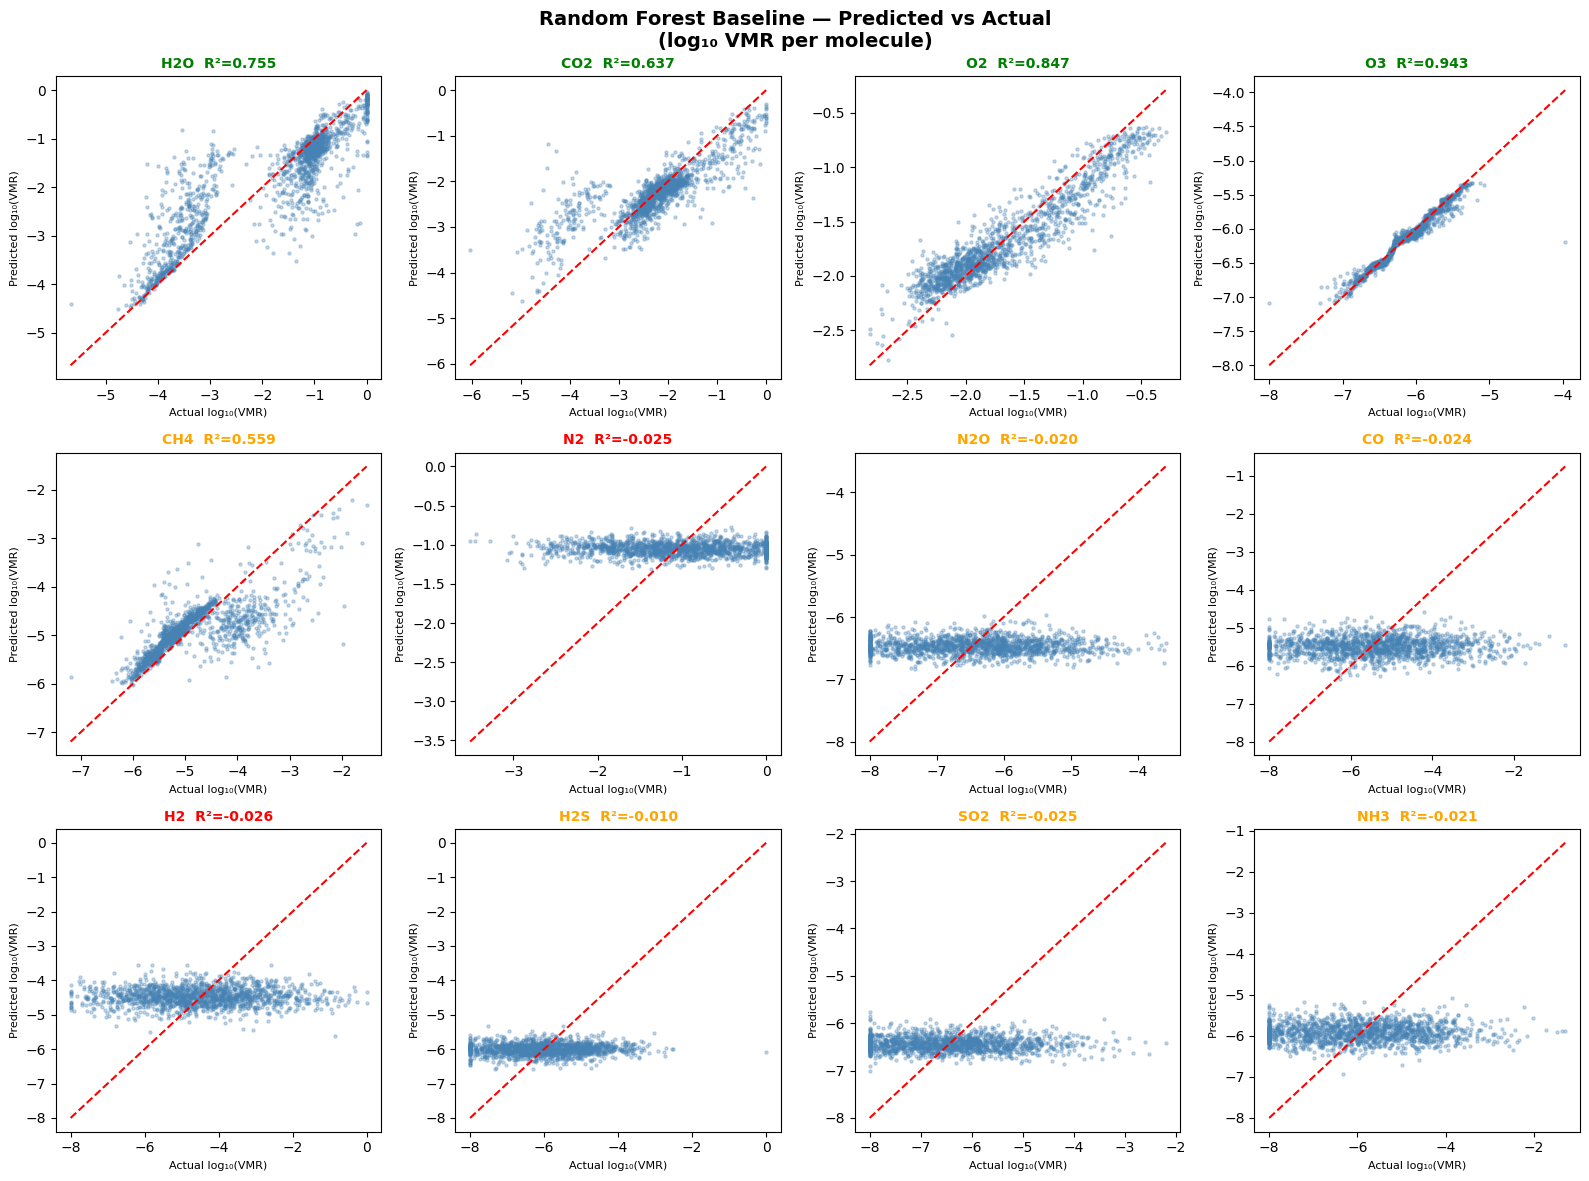

Plot saved to results/plots/rf_baseline_results.png ✓


In [9]:
# Cell 8 - Visualize Results
os.makedirs('../results/plots', exist_ok=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Random Forest Baseline — Predicted vs Actual\n(log₁₀ VMR per molecule)',
             fontsize=14, fontweight='bold')

for i, (mol, ax) in enumerate(zip(MOLECULES, axes.ravel())):
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.3, s=5, color='steelblue')
    mn = min(y_test[:, i].min(), y_pred[:, i].min())
    mx = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    
    if mol in STRONG_FEATURES:
        color = 'green'
    elif mol in WEAK_FEATURES:
        color = 'red'
    else:
        color = 'orange'
        
    ax.set_title(f'{mol}  R²={r2_list[i]:.3f}', 
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Actual log₁₀(VMR)', fontsize=8)
    ax.set_ylabel('Predicted log₁₀(VMR)', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/rf_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/plots/rf_baseline_results.png ✓")

In [12]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Define molecule names (same order as dataset)
MOLECULE_NAMES = [
    "H2O", "CO2", "O2", "O3",
    "CH4", "N2", "N2O", "CO",
    "H2", "H2S", "SO2", "NH3"
]

def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"\n{'='*40}")
    print(f"{model_name} Evaluation")
    print(f"{'='*40}")

    # Overall metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print("\nOverall Metrics:")
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

    # Per molecule
    print("\nPer Molecule Metrics:")
    for i in range(y_true.shape[1]):
        r2_i = r2_score(y_true[:, i], y_pred[:, i])
        rmse_i = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae_i = mean_absolute_error(y_true[:, i], y_pred[:, i])

        name = MOLECULE_NAMES[i] if i < len(MOLECULE_NAMES) else f"Molecule {i}"

        print(f"{name:>4} → R2={r2_i:.3f}, RMSE={rmse_i:.3f}, MAE={mae_i:.3f}")

In [14]:
# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
evaluate_model(y_test, y_pred, model_name="Random Forest")


Random Forest Evaluation

Overall Metrics:
R2   : 0.2992
RMSE : 0.9707
MAE  : 0.6759

Per Molecule Metrics:
 H2O → R2=0.755, RMSE=0.668, MAE=0.468
 CO2 → R2=0.637, RMSE=0.541, MAE=0.348
  O2 → R2=0.847, RMSE=0.211, MAE=0.168
  O3 → R2=0.943, RMSE=0.096, MAE=0.052
 CH4 → R2=0.559, RMSE=0.536, MAE=0.387
  N2 → R2=-0.025, RMSE=0.734, MAE=0.600
 N2O → R2=-0.020, RMSE=0.952, MAE=0.773
  CO → R2=-0.024, RMSE=1.436, MAE=1.158
  H2 → R2=-0.026, RMSE=1.538, MAE=1.229
 H2S → R2=-0.010, RMSE=1.120, MAE=0.904
 SO2 → R2=-0.025, RMSE=1.123, MAE=0.909
 NH3 → R2=-0.021, RMSE=1.355, MAE=1.115


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


## Optional

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree

sns.set(style="whitegrid")

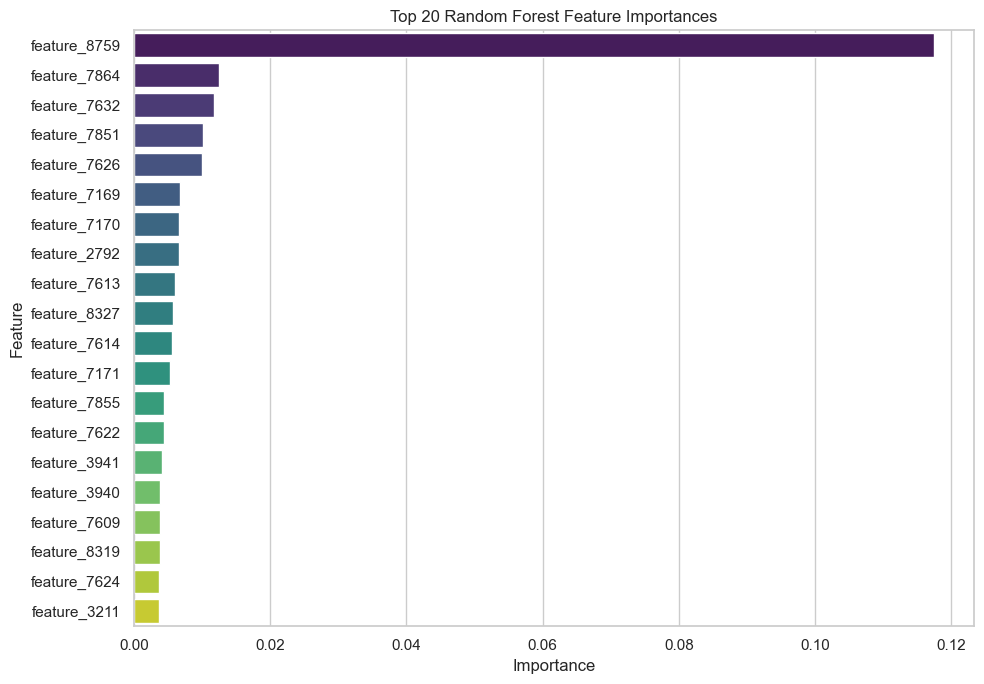

In [19]:
# Visualize feature importance from the trained Random Forest

if "rf_model" not in globals():
    raise RuntimeError("rf_model is not available in the notebook. Train the model first.")

importances = rf_model.feature_importances_

feature_names = [f"feature_{i}" for i in range(len(importances))]
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

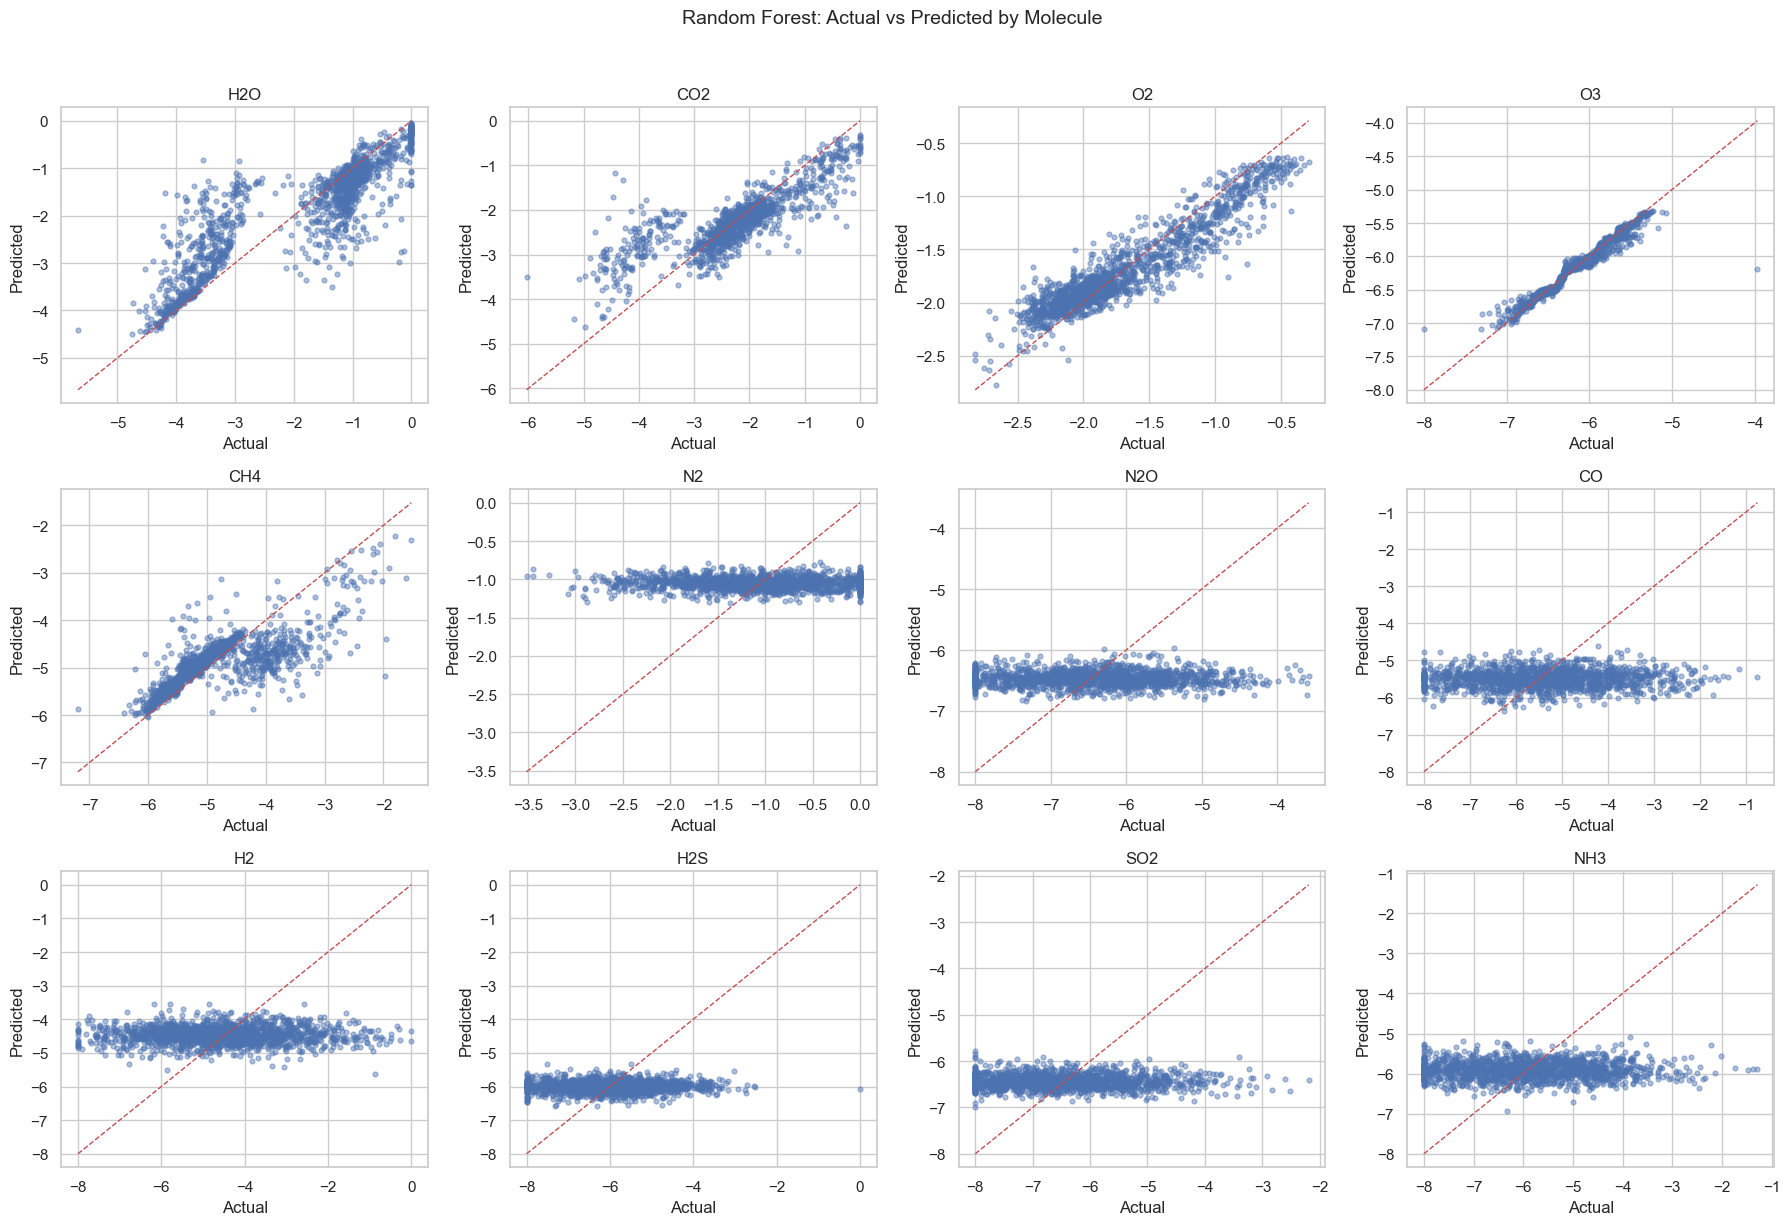

In [20]:
# Actual vs predicted plots for each molecule

molecules = ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, mol in enumerate(molecules):
    ax = axes[i]
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.45, s=12)
    mn = min(y_test[:, i].min(), y_pred[:, i].min())
    mx = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1)
    ax.set_title(mol)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.suptitle("Random Forest: Actual vs Predicted by Molecule", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

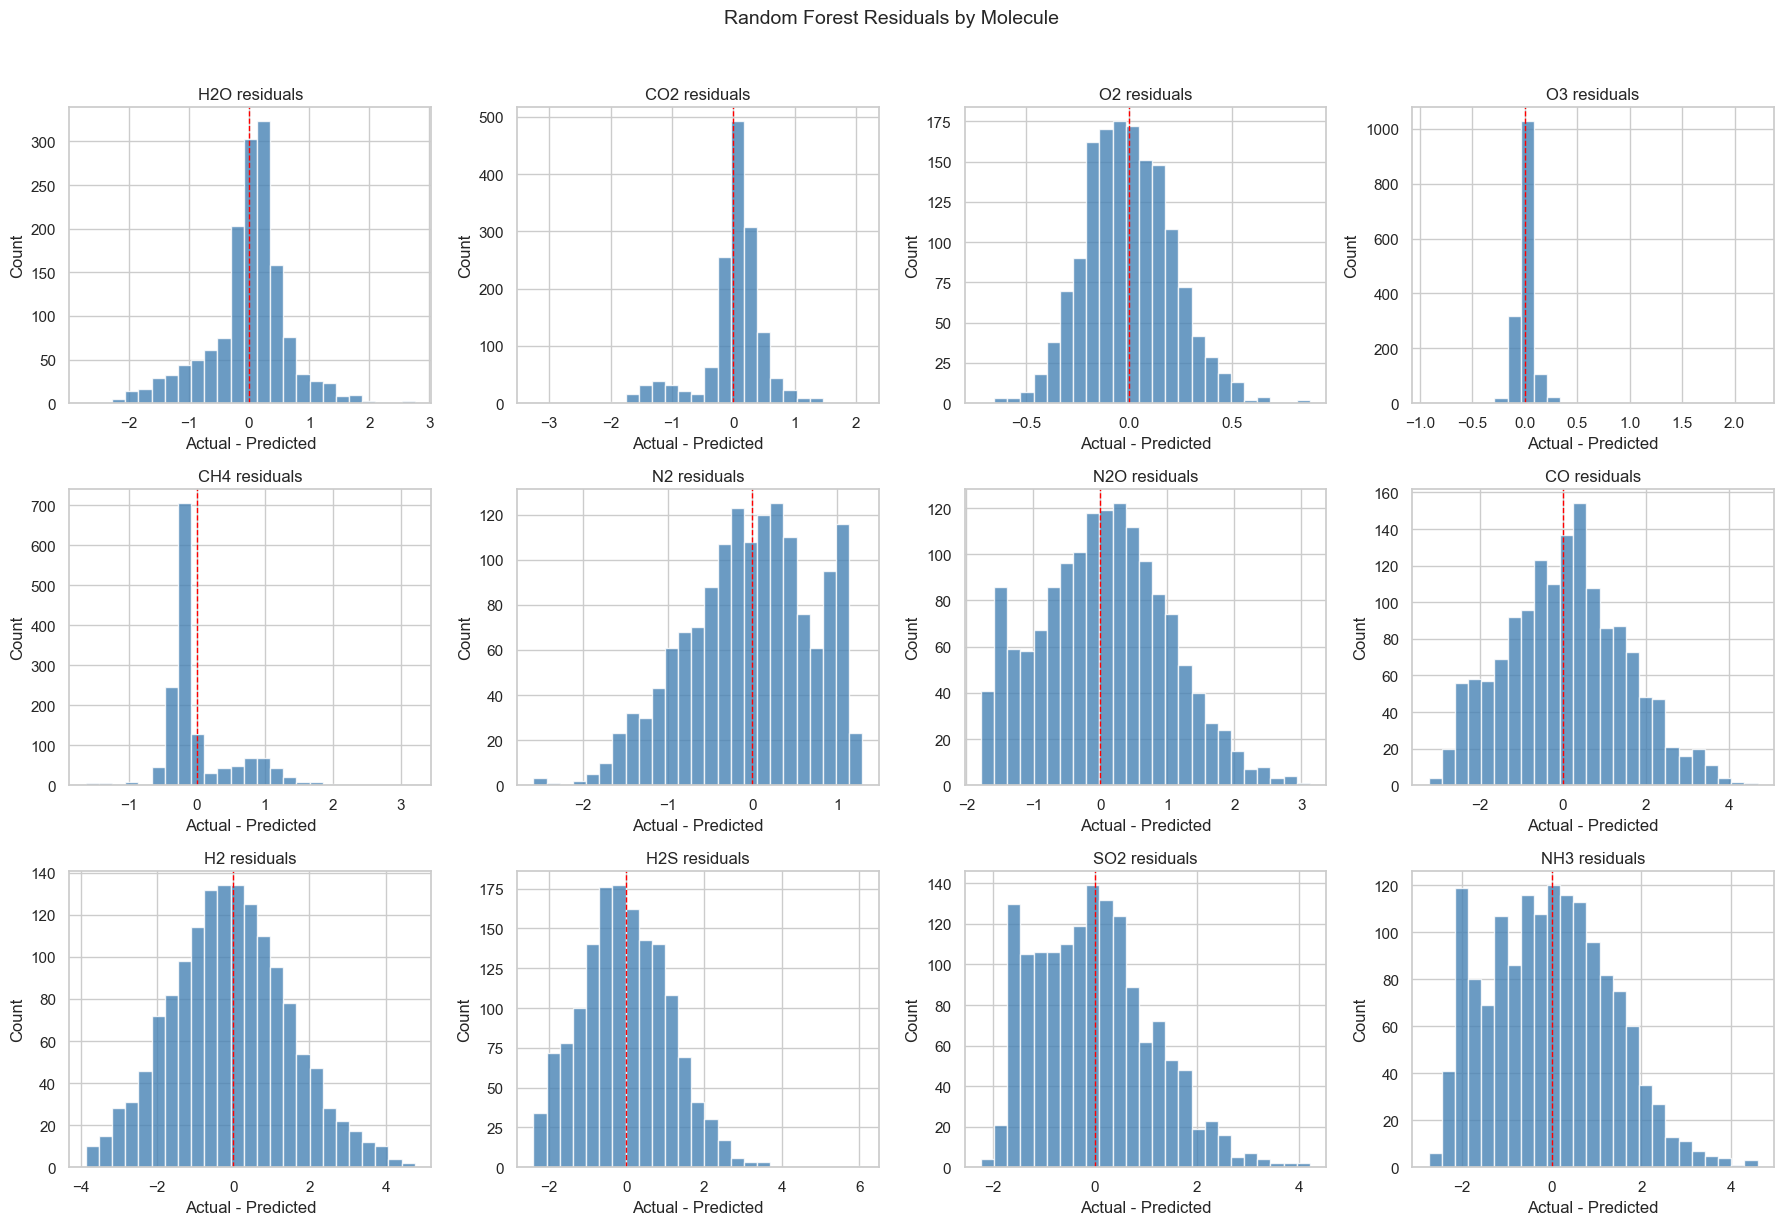

In [21]:
# Residual histograms

residuals = y_test - y_pred

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, mol in enumerate(molecules):
    ax = axes[i]
    ax.hist(residuals[:, i], bins=25, alpha=0.8, color="steelblue", edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1)
    ax.set_title(f"{mol} residuals")
    ax.set_xlabel("Actual - Predicted")
    ax.set_ylabel("Count")

plt.suptitle("Random Forest Residuals by Molecule", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

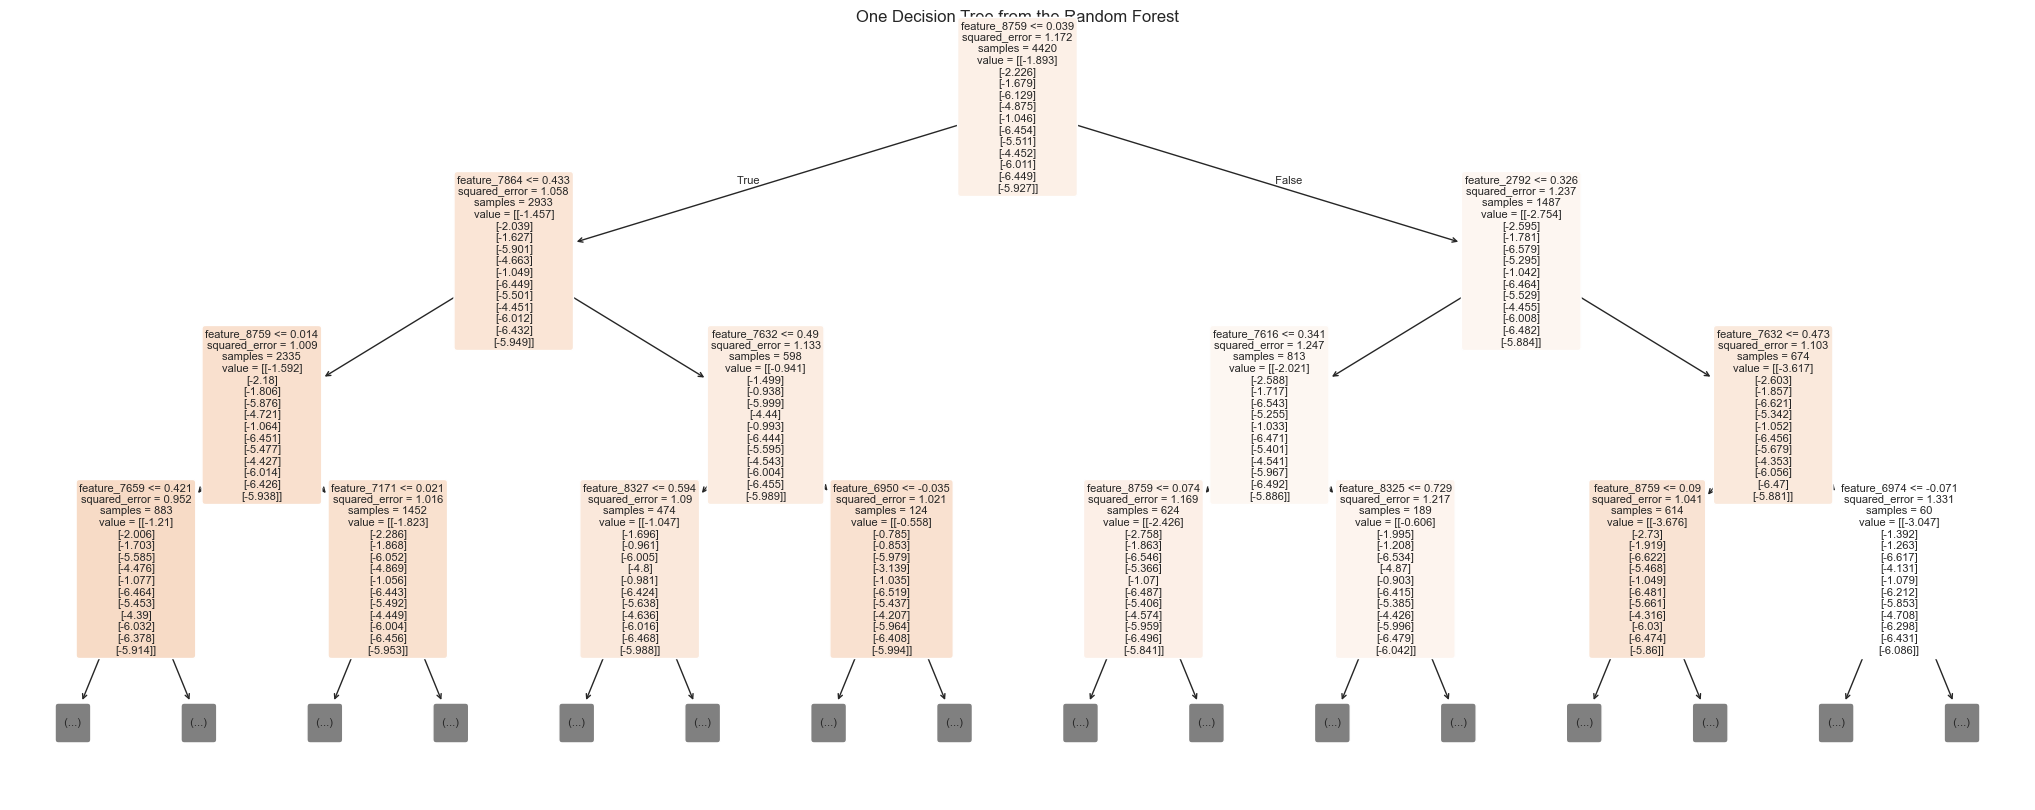

In [22]:
# Optional: visualize one tree from the forest
# Note: keep max_depth small, otherwise the plot becomes a forest of confusion.

tree = rf_model.estimators_[0]

plt.figure(figsize=(26, 10))
plot_tree(
    tree,
    max_depth=3,
    filled=True,
    rounded=True,
    feature_names=feature_names,
    fontsize=8
)
plt.title("One Decision Tree from the Random Forest")
plt.show()